In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


os.makedirs('outputs', exist_ok = True)

results = pd.read_csv("results.csv")

display(results.head(5))




,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [34]:

results.dropna(subset= ['home_score', 'away_score'])
#display(results.isnull().sum())




,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49210,2026-03-31,Kosovo,Turkey,0.0,1.0,FIFA World Cup qualification,Pristina,Kosovo,False
49211,2026-03-31,Czech Republic,Denmark,2.0,2.0,FIFA World Cup qualification,Prague,Czech Republic,False
49212,2026-03-31,Cameroon,China PR,2.0,0.0,FIFA Series,Melbourne,Australia,True
49213,2026-03-31,Australia,Curaçao,5.0,1.0,FIFA Series,Melbourne,Australia,False


In [35]:
results['target'] = 'draw'

results.loc[ results['home_score'] > results['away_score'], "target"] = 'home_win'
results.loc[ results['home_score'] < results['away_score'], "target"] = 'away_win'

split_date = '2020-01-01'
train = results[results['date'] < split_date].copy()
test = results[results['date'] >= split_date].copy()

print(results['target'].value_counts(normalize=True))

target
home_win    0.489094
away_win    0.282265
draw        0.228640
Name: proportion, dtype: float64


In [36]:
team_stats_list = []

team_names = pd.concat([ results['home_team'],results['away_team'] ]).unique()

for team in team_names:
    goals_scored = 0.0
    goals_conceded = 0.0
    team_data = train[(train['home_team'] == team) | (train['away_team'] == team)]
    total_match = len(team_data)
    if total_match == 0:
        continue

    total_win = len(team_data[ (((team_data['home_team'] == team) & (team_data['target'] == 'home_win' )) | 
                                (team_data['away_team'] == team) & (team_data['target'] == 'away_win' )) ])
    
    total_lost = len(team_data[ (((team_data['home_team'] == team) & (team_data['target'] == 'away_win' )) |
                    
                    (team_data['away_team'] == team) & (team_data['target'] == 'home_win' )) ])
    
    total_draw =  len( team_data[team_data['target'] == 'draw'])
    
    
    home_goals_scored = team_data [team_data['home_team'] == team] ['home_score'].sum()
    away_goals_scored = team_data [team_data['away_team'] == team] ['away_score'].sum()

    home_goals_conceded = team_data [team_data['home_team'] == team] ['away_score'].sum()
    away_goals_conceded = team_data [team_data['away_team'] == team] ['home_score'].sum()

    goals_scored = home_goals_scored + away_goals_scored
    goals_conceded = home_goals_conceded + away_goals_conceded

    team_stats_list.append({
        'Team': team,
        "Win rate": total_win / total_match,
        "Draw rate": total_draw / total_match,
        "Loss rate": total_lost / total_match, 
        "Avg goals scored": goals_scored / total_match,
        "Avg goals conceded": goals_conceded / total_match, 
        "Total matches played": total_match 
                                                      
    })

team_stat_df = pd.DataFrame(team_stats_list)
display(team_stat_df.head(5))

,Team,Win rate,Draw rate,Loss rate,Avg goals scored,Avg goals conceded,Total matches played
0,Scotland,0.475032,0.212548,0.312420,1.731114,1.235595,781
1,England,0.566898,0.239841,0.193261,2.188305,0.985134,1009
2,Wales,0.317073,0.214939,0.467988,1.253049,1.646341,656
3,Northern Ireland,0.257364,0.227907,0.514729,1.046512,1.888372,645
4,United States,0.429395,0.204611,0.365994,1.462536,1.380403,694


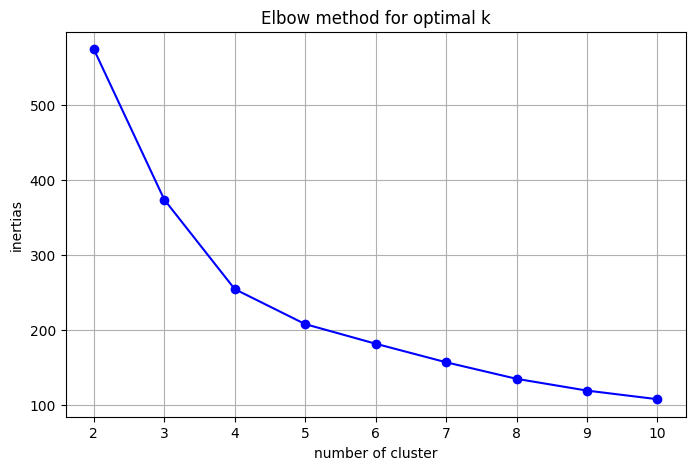

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["Win rate", "Avg goals scored", "Avg goals conceded"]
X = team_stat_df[features]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    inertias.append(kmeans.inertia_)


plt.figure(figsize = (8,5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("number of cluster")
plt.ylabel("inertias")
plt.grid(True)
plt.title("Elbow method for optimal k")
plt.savefig('outputs/elbow_curve.png', dpi=300, bbox_inches='tight')
plt.show()


In [38]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
team_stat_df['Cluster'] = kmeans.fit_predict(x_scaled)

for id in range(k):
    print(team_stat_df[team_stat_df['Cluster'] == id] ['Team'].head(10).tolist())

['Northern Ireland', 'Alderney', 'Finland', 'Luxembourg', 'Philippines', 'Estonia', 'Lithuania', 'Aruba', 'Bolivia', 'Dominica']
['England', 'Guernsey', 'Jersey', 'Netherlands', 'Germany', 'Basque Country', 'Brazil', 'Spain', 'Andalusia', 'Silesia']
['Kiribati', 'Niue', 'Palau', 'Micronesia', 'Sark', 'Chechnya', 'Darfur', 'Saint Pierre and Miquelon', 'Ryūkyū']
['Scotland', 'Wales', 'United States', 'Uruguay', 'Austria', 'Hungary', 'Argentina', 'Belgium', 'France', 'Guyana']


In [39]:
team_to_cluster = dict(zip(team_stat_df['Team'], team_stat_df['Cluster']))
train['home_cluster'] = train['home_team'].map(team_to_cluster)
train['away_cluster'] = train['away_team'].map(team_to_cluster)

#must be 0
print(train['home_cluster'].isnull().sum())
print(train['away_cluster'].isnull().sum())

0
0


In [40]:
from collections import defaultdict

def fast_form_features(train_df, team_names, n_matches=10):
    """
    Fast form calculation using dictionaries and cumulative storage.
    Runs in O(n) instead of O(n²).
    """
    # Initialize storage for each team's recent matches
    team_recent_matches = {team: [] for team in team_names}
    team_recent_goals = {team: {'scored': [], 'conceded': []} for team in team_names}
    
    # Prepare result columns
    home_forms = []
    away_forms = []
    home_avg_scored = []
    home_avg_conceded = []
    away_avg_scored = []
    away_avg_conceded = []
    
    # Process matches in chronological order
    for idx, row in train_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        date = row['date']
        home_score = row['home_score']
        away_score = row['away_score']
        
        # Calculate form for home team using stored history
        home_form = calculate_form_from_history(team_recent_matches[home], n_matches)
        away_form = calculate_form_from_history(team_recent_matches[away], n_matches)
        
        # Calculate goal averages
        home_avg_s, home_avg_c = calculate_goal_averages(team_recent_goals[home], n_matches)
        away_avg_s, away_avg_c = calculate_goal_averages(team_recent_goals[away], n_matches)
        
        # Store results
        home_forms.append(home_form)
        away_forms.append(away_form)
        home_avg_scored.append(home_avg_s)
        home_avg_conceded.append(home_avg_c)
        away_avg_scored.append(away_avg_s)
        away_avg_conceded.append(away_avg_c)
        
        # Update history for future matches
        update_team_history(team_recent_matches[home], home, home_score, away_score, date, is_home=True)
        update_team_history(team_recent_matches[away], away, home_score, away_score, date, is_home=False)
        update_team_goals(team_recent_goals[home], home_score, away_score, is_home=True)
        update_team_goals(team_recent_goals[away], home_score, away_score, is_home=False)
    
    # Add to dataframe
    train_df['home_form'] = home_forms
    train_df['away_form'] = away_forms
    train_df['home_avg_scored'] = home_avg_scored
    train_df['home_avg_conceded'] = home_avg_conceded
    train_df['away_avg_scored'] = away_avg_scored
    train_df['away_avg_conceded'] = away_avg_conceded
    
    return train_df

def calculate_form_from_history(history, n_matches):
    """Calculate points per game from last n matches in history"""
    if len(history) == 0:
        return 0.5  # Neutral
    
    recent = history[-n_matches:]
    total_points = sum(points for _, points, _, _ in recent)
    return total_points / n_matches

def calculate_goal_averages(goal_history, n_matches):
    """Calculate avg goals scored/conceded from last n matches"""
    if len(goal_history['scored']) == 0:
        return 1.0, 1.0
    
    recent_scored = goal_history['scored'][-n_matches:]
    recent_conceded = goal_history['conceded'][-n_matches:]
    
    avg_scored = sum(recent_scored) / len(recent_scored)
    avg_conceded = sum(recent_conceded) / len(recent_conceded)
    
    return avg_scored, avg_conceded

def update_team_history(history, team, home_score, away_score, date, is_home):
    """Update team's match history"""
    if is_home:
        if home_score > away_score:
            points = 3
        elif home_score == away_score:
            points = 1
        else:
            points = 0
    else:
        if away_score > home_score:
            points = 3
        elif away_score == home_score:
            points = 1
        else:
            points = 0
    
    history.append((date, points, home_score, away_score))

def update_team_goals(goal_history, home_score, away_score, is_home):
    """Update team's goal history"""
    if is_home:
        goal_history['scored'].append(home_score)
        goal_history['conceded'].append(away_score)
    else:
        goal_history['scored'].append(away_score)
        goal_history['conceded'].append(home_score)

In [41]:
train = train.sort_values('date').reset_index(drop=True)

# Get all team names
team_names = pd.concat([train['home_team'], train['away_team']]).unique()

# Run fast form calculation (should take 20-40 seconds)
train = fast_form_features(train, team_names, n_matches=5)

print("Done! Check results:")
print(train[['home_team', 'away_team', 'home_form', 'away_form']].head())


Done! Check results:
  home_team away_team  home_form  away_form
0  Scotland   England        0.5        0.5
1   England  Scotland        0.2        0.2
2  Scotland   England        0.2        0.8
3   England  Scotland        0.8        0.8
4  Scotland   England        1.0        1.0


In [42]:
print(train['tournament'].value_counts())
top_tournament = train['tournament'].value_counts().head(10).to_list()
for tournament in top_tournament:
    train[f'tournament_{tournament}'] = (train['tournament'] == tournament).astype(int)

train['is_neutral'] = train['neutral'].astype(int)


tournament
Friendly                                16796
FIFA World Cup qualification             7140
UEFA Euro qualification                  2573
African Cup of Nations qualification     1938
FIFA World Cup                            900
                                        ...  
The Other Final                             1
TIFOCO Tournament                           1
Copa Confraternidad                         1
ConIFA Challenger Cup                       1
Benedikt Fontana Cup                        1
Name: count, Length: 168, dtype: int64


In [43]:
#define all features
features_columns = ['home_cluster', 'away_cluster',
                    'home_form', 'away_form',
                    'home_avg_scored', 'home_avg_conceded',
                    'away_avg_scored', 'away_avg_conceded',
                    'is_neutral'

                    
                    ] + [col for col in train.columns if col.startswith("tournament_")] 

target_map = {'away_win' : 0,
              'draw' : 1,
              'home_win': 2}

X = train[features_columns]
train['target_numeric'] = train['target'].map(target_map)
y = train['target_numeric']

print(f'before handling missing values\n{ X.isnull().sum()}')
X = X.fillna(X.median())
print(f'\nafter handling missing values\n{X.isnull().sum()}')

print(f'Final feature set: {X.shape[1]} features')
print(f'Features: {features_columns}')

before handling missing values
home_cluster         0
away_cluster         0
home_form            0
away_form            0
home_avg_scored      0
home_avg_conceded    0
away_avg_scored      0
away_avg_conceded    0
is_neutral           0
tournament_16796     0
tournament_7140      0
tournament_2573      0
tournament_1938      0
tournament_900       0
tournament_809       0
tournament_724       0
tournament_689       0
tournament_620       0
tournament_606       0
dtype: int64

after handling missing values
home_cluster         0
away_cluster         0
home_form            0
away_form            0
home_avg_scored      0
home_avg_conceded    0
away_avg_scored      0
away_avg_conceded    0
is_neutral           0
tournament_16796     0
tournament_7140      0
tournament_2573      0
tournament_1938      0
tournament_900       0
tournament_809       0
tournament_724       0
tournament_689       0
tournament_620       0
tournament_606       0
dtype: int64
Final feature set: 19 features
Feature

In [44]:
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Try different values and keep the best
best_acc = 0
best_model = None
best_estimators = None

for estimators in [200, 300, 500, 700]:
    model = XGBClassifier(
        n_estimators=estimators,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False
    )
    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    print(f"Estimators {estimators}: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_estimators = estimators

print(f"\nBest model: {best_estimators} estimators with accuracy {best_acc:.4f}")

# Use the best model for predictions
y_pred = best_model.predict(X_val)
y_pred_prob = best_model.predict_proba(X_val)

print(f'\nFinal Accuracy: {accuracy_score(y_val, y_pred):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_val, y_pred))

c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:18:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Estimators 200: 0.5517


c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:18:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Estimators 300: 0.5517


c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:18:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Estimators 500: 0.5495


c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:18:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Estimators 700: 0.5495

Best model: 200 estimators with accuracy 0.5517

Final Accuracy: 0.5517

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.43      0.47      2437
           1       0.23      0.00      0.01      1967
           2       0.56      0.88      0.69      4264

    accuracy                           0.55      8668
   macro avg       0.44      0.44      0.39      8668
weighted avg       0.48      0.55      0.47      8668



In [45]:
baseline_prediction = [target_map['home_win']] * len(y_val)
baseline_accuracy = accuracy_score(y_val, baseline_prediction)

print(f'Baseline (always home_win) accuracy: {baseline_accuracy:.4f}')
print(f'XGBoost accuracy: {accuracy_score(y_val, y_pred):.4f}')
print(f'Improvement: {(accuracy_score(y_val, y_pred) - baseline_accuracy) * 100:.1f}%')

#cross-validation

cv_scores = cross_val_score(best_model, X, y, cv = 5)
print(f'\n5-fold cross-validation scores: {cv_scores}')
print(f'Mean CV accuracy: {cv_scores.mean():.4f} (+/-) {cv_scores.std()*2:.4f}')


Baseline (always home_win) accuracy: 0.4919
XGBoost accuracy: 0.5517
Improvement: 6.0%


c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:18:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:18:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:18:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\arthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [08:18:19] WARNING: C:\actio


5-fold cross-validation scores: [0.5372635  0.55064605 0.54880018 0.5571066  0.5570555 ]
Mean CV accuracy: 0.5502 (+/-) 0.0145


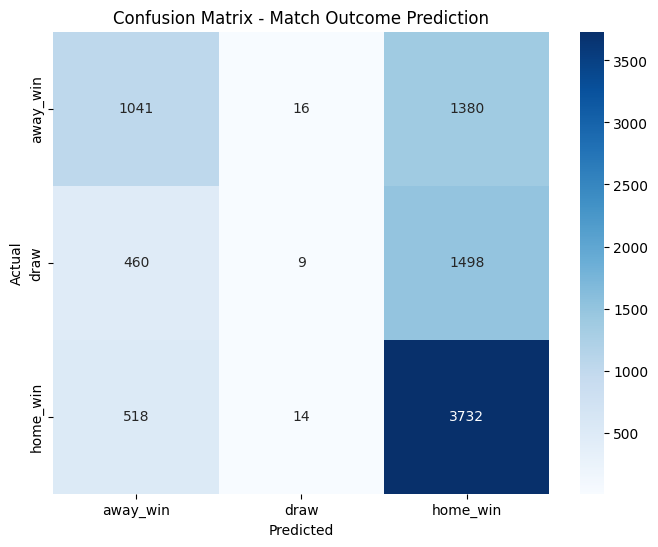

In [46]:
#confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot = True, fmt='d', cmap='Blues',
            xticklabels=['away_win', 'draw', 'home_win'],
            yticklabels=['away_win', 'draw', 'home_win'])

plt.title('Confusion Matrix - Match Outcome Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('outputs/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

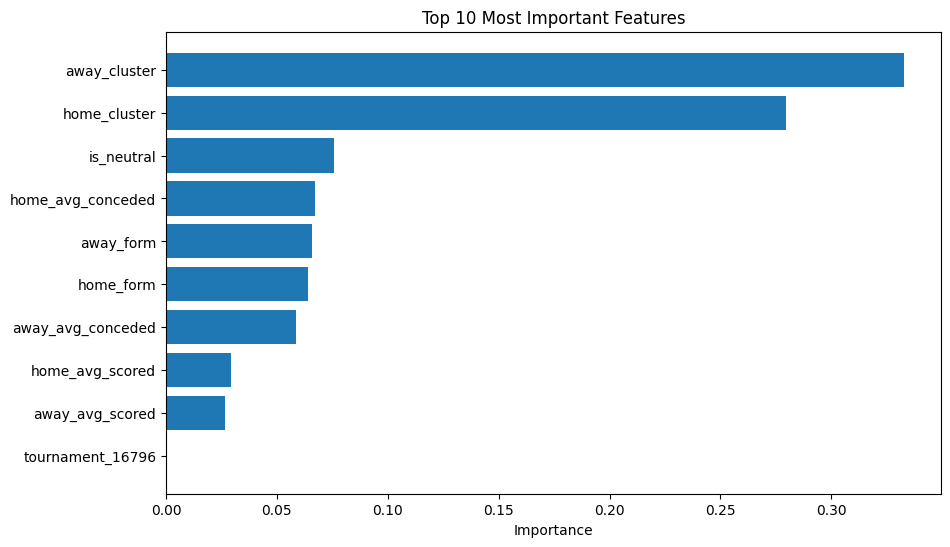

In [47]:
#feature importance
feature_importance = pd.DataFrame({
    'feature': features_columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending = False)

plt.figure(figsize = (10, 6))
plt.barh(feature_importance['feature'].head(10), feature_importance['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.savefig('outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

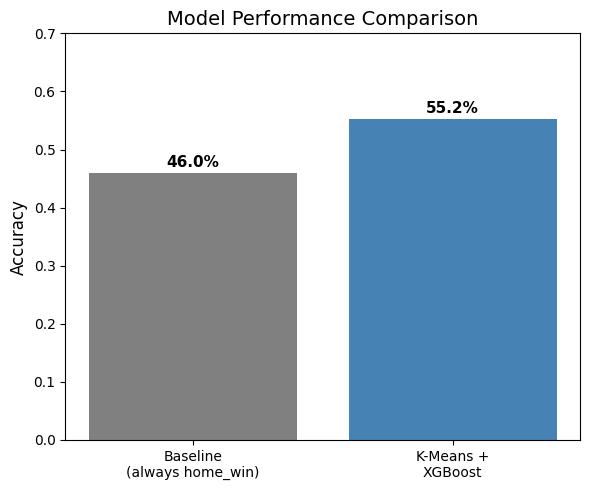

In [48]:

models = ['Baseline\n(always home_win)', 'K-Means +\nXGBoost']
accuracies = [0.460, 0.552]

plt.figure(figsize=(6, 5))
bars = plt.bar(models, accuracies, color=['gray', 'steelblue'])
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0, 0.7)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.1%}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()